In [2]:
#needed libraries:
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import plotly.express as px

In [3]:
df = pd.read_csv("group_31_train.csv")

In [4]:
#General Understanding of the Dataset

print("Shape of data:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values summary:")
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_summary)

Shape of data: (100000, 35)

Column names:
['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'y']

Data types:


,dtype
f1,str
f2,str
f3,float64
f4,float64
f5,float64
f6,float64
f7,str
f8,str
f9,str
f10,str



Missing values summary:


,missing_count,missing_percent
f4,43853,43.853
f5,43853,43.853
f20,28806,28.806
f19,7498,7.498
f18,2276,2.276
f16,2208,2.208
f17,1812,1.812
f15,1533,1.533
f14,304,0.304
f32,290,0.290


In [5]:
#ِDeep dive into categorical / bool / string columns:

target_col = "y"

categorical_cols = (
    df.select_dtypes(
        include=["object", "string", "category", "bool"]
    )
    .columns
    .tolist()
)

if target_col in df.columns and target_col not in categorical_cols:
    categorical_cols = [target_col] + categorical_cols

print("Categorical / Bool / string columns:")
print(categorical_cols)

categorical_summary = []

for col in categorical_cols:
    categorical_summary.append({
        "column": col,
        "dtype": df[col].dtype,
        "unique_count": df[col].nunique(dropna=True),
        "missing_count": df[col].isna().sum(),
        "missing_percent": df[col].isna().mean() * 100
    })

categorical_summary = pd.DataFrame(categorical_summary)
display(categorical_summary.sort_values("unique_count", ascending=False))


# Unique values :
for col in categorical_cols:
    print("=" * 80)
    print(f"Column: {col}")
    print(f"Unique values count: {df[col].nunique(dropna=True)}")
    print(f"Missing values: {df[col].isna().sum()}")
    
    display(
        df[col]
        .value_counts(dropna=False)
        .to_frame("count")
        .assign(percent=lambda x: x["count"] / len(df) * 100)
    )


Categorical / Bool / string columns:
['y', 'f1', 'f2', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f18', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']


,column,dtype,unique_count,missing_count,missing_percent
2,f2,str,99438,0,0.000
3,f7,str,92402,0,0.000
11,f15,str,78150,1533,1.533
8,f12,str,36832,30,0.030
4,f8,str,32350,140,0.140
5,f9,str,6292,2,0.002
10,f14,str,1596,304,0.304
6,f10,str,1279,0,0.000
7,f11,str,49,0,0.000
12,f18,str,24,2276,2.276


Column: y
Unique values count: 4
Missing values: 0


,count,percent
y,,
2,79621,79.621
3,16871,16.871
4,2631,2.631
1,877,0.877


Column: f1
Unique values count: 3
Missing values: 0


...

,count,percent
f32,,
Day,69081,69.081
Night,30629,30.629
NaN,290,0.290


Column: f33
Unique values count: 2
Missing values: 290


,count,percent
f33,,
Day,78645,78.645
Night,21065,21.065
NaN,290,0.290


Column: f34
Unique values count: 2
Missing values: 290


,count,percent
f34,,
Day,82519,82.519
Night,17191,17.191
NaN,290,0.290


Based on the values in feature `f7`, we guessed that the dataset could be related to traffic accidents. This also suggests that the other features may contain information about the accident location, geographical details, and environmental conditions at the time of the accident.

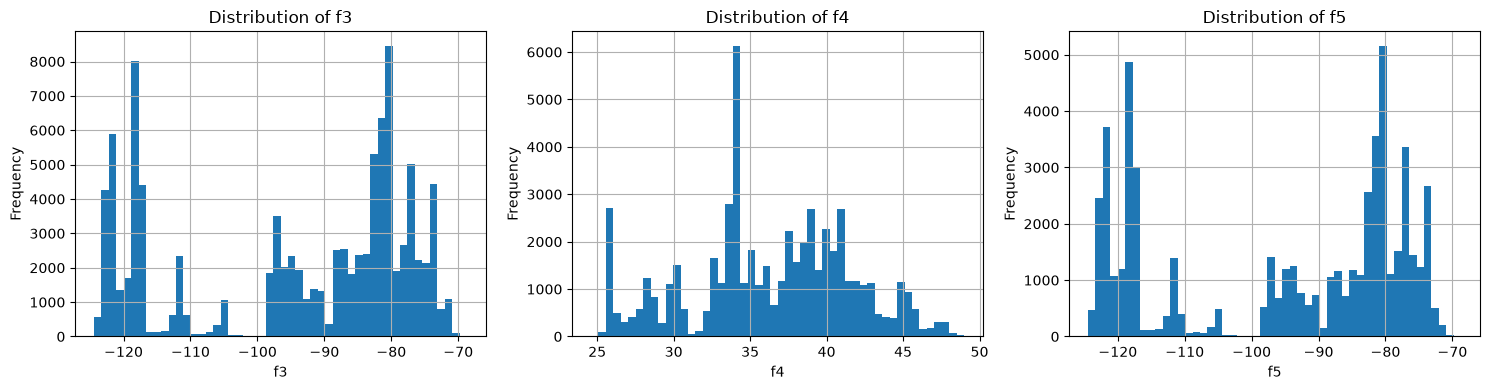

In [15]:
# Checking the Range of f3, f4 and f5

cols_for_plot = ["f3", "f4" , "f5"]

n_cols = 3
n_rows = math.ceil(len(cols_for_plot) / n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(cols_for_plot, 1):
    plt.subplot(n_rows, n_cols, i)
    df[col].dropna().hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


We used the missing-value patterns to check whether some columns might be related.

If two columns are usually missing in the same rows, there is a higher chance that they are semantically connected or form a pair:



In [ ]:
# Checking Relationships Between Missing Values:


missing_pattern = df.isna().astype(int).corr()

upper_triangle = np.triu(
    np.ones(missing_pattern.shape, dtype=bool),
    k=1
)

perfect_missing_pairs = (
    missing_pattern
    .where(upper_triangle)
    .stack()
    .loc[lambda x: np.isclose(x, 1)]
    .sort_values(ascending=False)
)

print(perfect_missing_pairs)

f4   f5     1.0
f32  f33    1.0
     f34    1.0
f33  f34    1.0
dtype: float64


By looking at a few samples from `f8` to `f11`and `f13`, it became clear that these columns represent address-related information, which is likely the accident location: 
- `f8`: street / highway / state route name 
- `f9`: city 
- `f10`: county 
- `f11`: state 
- `f13`: country

Based on this, the similar value ranges of `f4` and `f5`(`f3`), and the possibility that they form a related pair, we guessed that these two features might represent the geographical coordinates `(x, y)` of the accident location.


In [6]:
# showing f4, f5 on the usa map:

map_df = df[["f4", "f5"]].copy()


map_df["f4"] = pd.to_numeric(map_df["f4"], errors="coerce")
map_df["f5"] = pd.to_numeric(map_df["f5"], errors="coerce")

# dropping null values
map_df = map_df.dropna(subset=["f4", "f5"])

# plotting
fig = px.scatter_geo(
    map_df,
    lon="f5",
    lat="f4",
    scope="usa",
    title="Geographical Distribution of Data Points in the USA",
    labels={
        "f5": "Longitude",
        "f4": "Latitude"
    }
)

fig.update_traces(
    marker={
        "size": 5,
        "opacity": 0.6
    }
)

fig.update_geos(
    showland=True,
    showlakes=True,
    showcountries=True,
    showsubunits=True,   # showing states
    # fitbounds="locations"
)

fig.show()


After plotting the coordinates and manually checking a few samples on Google Maps, we concluded that `(f5, f4)` represents the geographical coordinates `(x, y)` of the accident location.



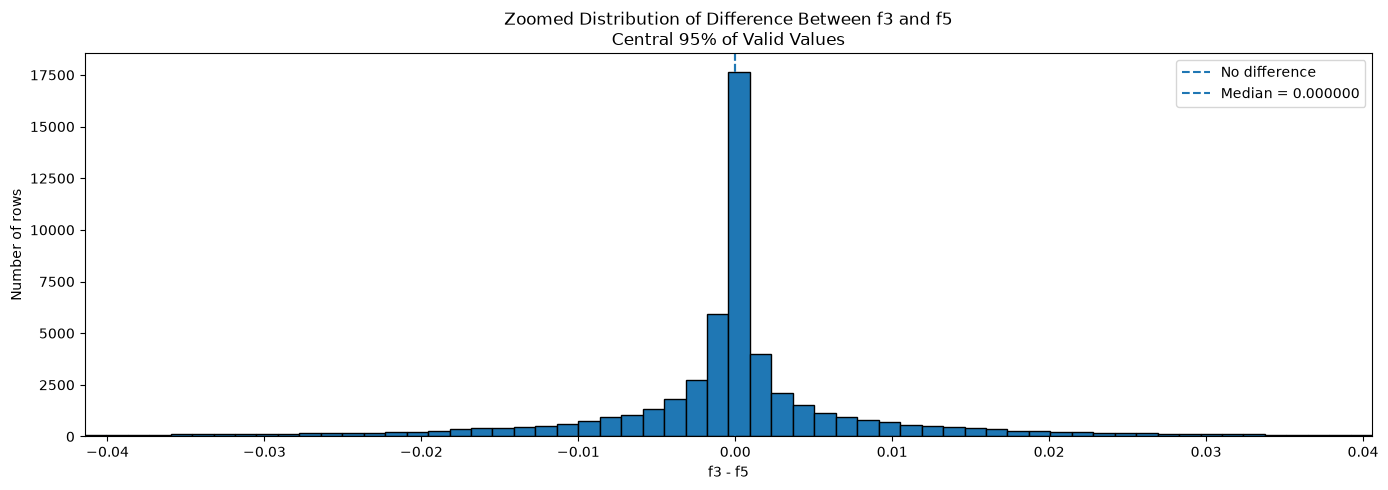

Total rows: 100000
Valid differences: 56147
Missing or invalid rows excluded: 43853
Rows shown in zoomed histogram: 53339
Rows outside zoomed range: 2808
Zoom range: -0.041457 to 0.040587


In [ ]:
# Checking the Difference Between f3 and f5

f3 = pd.to_numeric(df["f3"], errors="coerce")
f5 = pd.to_numeric(df["f5"], errors="coerce")

difference = (f3 - f5).dropna()

lower_limit = difference.quantile(0.025)
upper_limit = difference.quantile(0.975)

zoomed_difference = difference.between(
    lower_limit,
    upper_limit
)

zoomed_difference = difference[zoomed_difference]

bins_count = 60

plt.figure(figsize=(14, 5))

plt.hist(
    zoomed_difference,
    bins=bins_count,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="No difference"
)

plt.axvline(
    zoomed_difference.median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median = {zoomed_difference.median():.6f}"
)

plt.title(
    "Zoomed Distribution of Difference Between f3 and f5\n"
    "Central 95% of Valid Values"
)
plt.xlabel("f3 - f5")
plt.ylabel("Number of rows")

plt.xlim(lower_limit, upper_limit)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total rows: {len(df)}")
print(f"Valid differences: {len(difference)}")
print(f"Missing or invalid rows excluded: {len(df) - len(difference)}")
print(f"Rows shown in zoomed histogram: {len(zoomed_difference)}")
print(f"Rows outside zoomed range: {len(difference) - len(zoomed_difference)}")
print(f"Zoom range: {lower_limit:.6f} to {upper_limit:.6f}")

The values in `f3` are very close to those in `f4` and `f5`, so it may also contain geographical information.

However, the missing-value patterns only supported `f4` and `f5` as a clear pair. Therefore, we could not make a reliable conclusion about `f3` at this stage.



The values in `f12` are either five-digit numbers or follow a format like `12345-6789`.

After searching a few samples, and considering that `f8` to `f11` and `f13` contain address-related information, we concluded that `f12` represents the ZIP Code.



The values in `f14` are four-letter codes such as:

* `KLGA`
* `KFMY`
* `KHHR`
* `KORD`

The letter `K` appears at the beginning of many airport and weather-station codes in the United States. Based on this pattern, we guessed that `f14` represents a weather station or airport code.


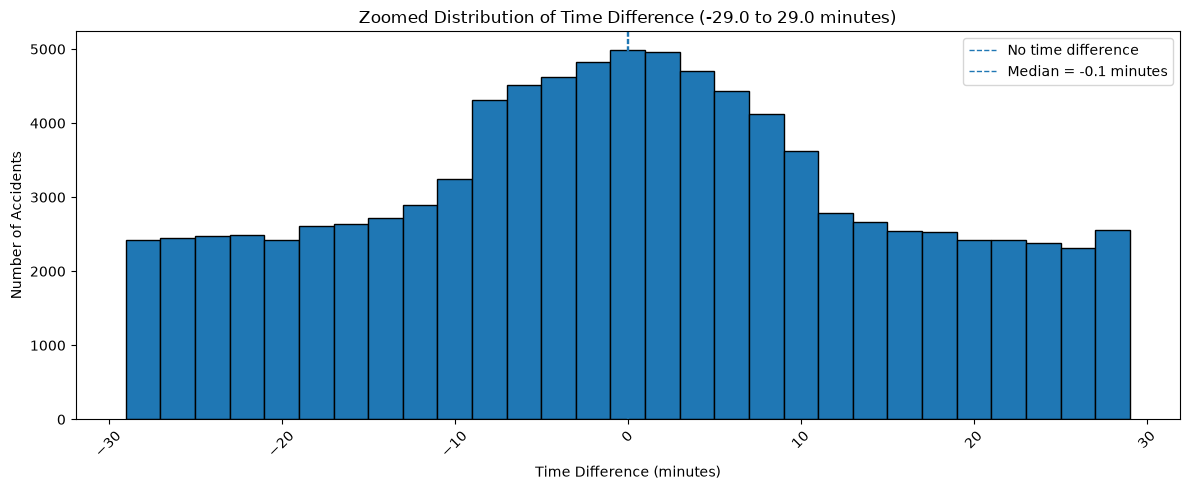

Total valid rows: 98467
Rows shown in zoomed histogram: 94073
Rows outside zoomed range: 4394


count    98467.000000
mean        -0.631793
std         41.613491
min      -1306.950000
25%        -11.500000
50%          0.000000
75%         11.066667
max       1216.900000
dtype: float64

In [ ]:
# Checking the Time Difference Between f2 and f15

time_1 = pd.to_datetime(df["f2"], format="mixed", errors="coerce")
time_2 = pd.to_datetime(df["f15"], format="mixed", errors="coerce")

difference = (time_1 - time_2).dt.total_seconds() / 60

valid_difference = difference.dropna()

zoom_limit = valid_difference.abs().quantile(0.95)


zoomed_difference = valid_difference[
    valid_difference.between(-zoom_limit, zoom_limit)
]

bin_width = 2

bins = np.arange(
    -zoom_limit,
    zoom_limit + bin_width,
    bin_width
)

plt.figure(figsize=(12, 5))

plt.hist(
    zoomed_difference,
    bins=bins,
    edgecolor="black"
)

plt.title(
    f"Zoomed Distribution of Time Difference "
    f"(-{zoom_limit:.1f} to {zoom_limit:.1f} minutes)"
)
plt.xlabel("Time Difference (minutes)")
plt.ylabel("Number of Accidents")

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
    label="No time difference"
)

plt.axvline(
    zoomed_difference.median(),
    linestyle="--",
    linewidth=1,
    label=f"Median = {zoomed_difference.median():.1f} minutes"
)

plt.xticks(
    np.arange(
        np.floor(-zoom_limit / 10) * 10,
        np.ceil(zoom_limit / 10) * 10 + 10,
        10
    ),
    rotation=45
)

plt.legend()
plt.tight_layout()
plt.show()

print(f"Total valid rows: {len(valid_difference)}")
print(f"Rows shown in zoomed histogram: {len(zoomed_difference)}")
print(f"Rows outside zoomed range: {len(valid_difference) - len(zoomed_difference)}")


difference.describe()

Based on the histogram, the timestamps in `f2` and `f15` are usually very close to each other.

Also, the values in `f15` are rounded timestamps without seconds. This suggests that `f2` represents the accident time, while `f15` represents the time when the weather and environmental conditions near the accident location were recorded.


Since `f1` only contains the values `source1`, `source2`, and `source3`, we named this feature `Source`.

Also, values in `f18`, such as `Calm`, `S`, `SSE`, and `N`, suggest that this feature represents the wind direction.


Target distribution:


,count,percent
y,,
2,79621,79.621
3,16871,16.871
4,2631,2.631
1,877,0.877


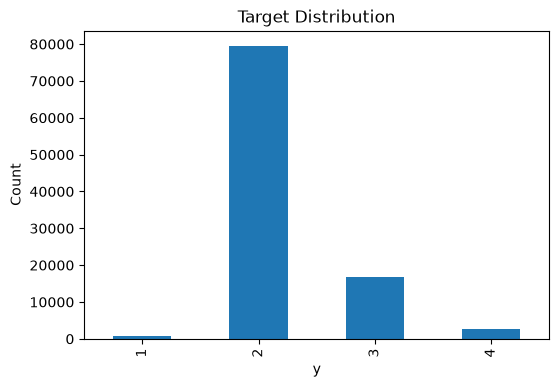

In [19]:
# Checking target distribution :

if target_col in df.columns:
    print("Target distribution:")
    target_dist = (
        df[target_col]
        .value_counts(dropna=False)
        .to_frame("count")
        .assign(percent=lambda x: x["count"] / len(df) * 100)
    )
    display(target_dist)

    plt.figure(figsize=(6, 4))
    df[target_col].value_counts().sort_index().plot(kind="bar")
    plt.title("Target Distribution")
    plt.xlabel(target_col)
    plt.ylabel("Count")
    plt.show()


After searching and confirming with the TA, we found that `y` represents the accident severity level on a scale from `1` to `4`.


In [ ]:
# Creating a new csv file :
column_names = {
    "f1": "Source",
    "f2": "Accident_Time",
    "f3": "Additional_Lng",
    "f4": "Lat",
    "f5": "Lng",
    "f7": "Description",
    "f8": "Street",
    "f9": "City",
    "f10": "County",
    "f11": "State",
    "f12": "Zipcode",
    "f13": "Country",
    "f14": "Airport_Code",
    "f15": "Weather_Time",
    "f18": "Wind_Direction"
}

df = df.rename(columns=column_names)

df.to_csv(
    "initial_data_renamed.csv",
    index=False,
    encoding="utf-8-sig"
)